## Introduction

## Time-Series Momentum in Action

We begin with the simplest possible example: one asset.

At the end of each month, we compute the asset’s trailing 12-month return.  
If that trailing return is positive, the signal is long. If it is negative, the signal is short.

Formally, define the signal at month-end \(t\) as

$$
s_t = \operatorname{sign}(r_{t-12:t})
$$

To avoid lookahead bias, the position held during month \(t\) is based on the signal formed at the end of month \(t-1\). Therefore, the strategy return in month \(t\) is

$$
r^{\mathrm{TSMOM}}_t = s_{t-1} \cdot r_t
$$

This first example is not meant to fully establish the paper’s cross-asset result. Its goal is to make the mechanics of time-series momentum intuitive before moving to the diversified multi-asset case.

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from pathlib import Path

def load_yahoo_close(ticker: str, data_dir: str = "data", refresh: bool = False) -> pd.Series:
    data_path = Path(data_dir)
    data_path.mkdir(parents=True, exist_ok=True)

    file_path = data_path / f"{ticker}_daily_adj_close.csv"

    if file_path.exists() and not refresh:
        px = pd.read_csv(file_path, index_col=0, parse_dates=True)["Close"].dropna()
        px = px.sort_index()
        px.name = "Close"
        print(f"Loaded {ticker} from cache: {file_path} | rows={len(px)}")
        return px

    df = yf.download(
        ticker,
        period="max",
        auto_adjust=True,
        progress=False
    )

    if df.empty:
        raise ValueError(f"No data downloaded for ticker '{ticker}'")

    px = df["Close"]
    if isinstance(px, pd.DataFrame):
        px = px.iloc[:, 0]

    px = px.dropna().sort_index()
    px.name = "Close"

    px.to_frame().to_csv(file_path)
    print(f"Downloaded {ticker} from Yahoo and saved to: {file_path} | rows={len(px)}")

    return px


ticker = "SPY"
# Use the cached CSV by default; set refresh=True only when you want to update.
px = load_yahoo_close(ticker, refresh=False)
px.tail()

Loaded SPY from cache: data/SPY_daily_adj_close.csv | rows=8348


Date
2026-03-24    653.179993
2026-03-25    656.820007
2026-03-26    645.090027
2026-03-27    634.090027
2026-03-30    635.590027
Name: Close, dtype: float64

In [49]:
print(px.index.min(), px.index.max(), len(px))

1993-01-29 00:00:00 2026-03-30 00:00:00 8348


In [50]:
# --- Convert daily prices to month-end prices and monthly returns ---
px_m = px.resample("ME").last()
r_m = px_m.pct_change().rename("asset_return")

# --- Trailing 12-month return ---
# (1+r_t)...(1+r_{t-11}) - 1
trailing_12m = ((1 + r_m).rolling(12).apply(np.prod, raw=True) - 1).rename("trailing_12m")

# --- Time-series momentum signal at time t ---
# +1 if trailing 12m return > 0, -1 if < 0, 0 otherwise
signal = pd.Series(
    np.where(trailing_12m > 0, 1, np.where(trailing_12m < 0, -1, 0)),
    index=trailing_12m.index,
    name="signal"
)

pd.concat([px_m.rename("month_end_price"), r_m, trailing_12m, signal], axis=1).tail(15)

,month_end_price,asset_return,trailing_12m,signal
Date,,,,
2025-01-31,593.214722,0.026856,0.262301,1
2025-02-28,585.683899,-0.012695,0.184463,1
2025-03-31,553.050049,-0.055719,0.083047,1
2025-04-30,548.255005,-0.008670,0.118765,1
2025-05-31,582.710144,0.062845,0.131827,1
2025-06-30,612.653381,0.051386,0.149435,1
2025-07-31,626.763672,0.023031,0.161839,1
2025-08-31,639.624573,0.020520,0.158608,1
2025-09-30,662.408264,0.035620,0.175194,1


In [51]:
# --- Position held during month t is based on signal from month t-1 ---
position = signal.shift(1).rename("position")

# --- Strategy return ---
strategy_r = (position * r_m).rename("strategy_return")

# --- Combine everything in one table ---
out = pd.concat(
    [px_m.rename("month_end_price"), r_m, trailing_12m, signal, position, strategy_r],
    axis=1
).dropna()

# --- How often is the strategy long vs short? ---
position_counts = out["position"].value_counts().sort_index()
long_frac = (out["position"] > 0).mean()
short_frac = (out["position"] < 0).mean()
flat_frac = (out["position"] == 0).mean()

print("Position counts:")
print(position_counts)
print()
print(f"Long fraction:  {long_frac:.2%}")
print(f"Short fraction: {short_frac:.2%}")
print(f"Flat fraction:  {flat_frac:.2%}")

out.tail(15)

Position counts:
position
-1.0     70
 0.0      1
 1.0    316
Name: count, dtype: int64

Long fraction:  81.65%
Short fraction: 18.09%
Flat fraction:  0.26%


,month_end_price,asset_return,trailing_12m,signal,position,strategy_return
Date,,,,,,
2025-01-31,593.214722,0.026856,0.262301,1,1.0,0.026856
2025-02-28,585.683899,-0.012695,0.184463,1,1.0,-0.012695
2025-03-31,553.050049,-0.055719,0.083047,1,1.0,-0.055719
2025-04-30,548.255005,-0.008670,0.118765,1,1.0,-0.008670
2025-05-31,582.710144,0.062845,0.131827,1,1.0,0.062845
2025-06-30,612.653381,0.051386,0.149435,1,1.0,0.051386
2025-07-31,626.763672,0.023031,0.161839,1,1.0,0.023031
2025-08-31,639.624573,0.020520,0.158608,1,1.0,0.020520
2025-09-30,662.408264,0.035620,0.175194,1,1.0,0.035620


In [52]:
# --- Cumulative returns ---
asset_cum = (1 + out["asset_return"]).cumprod().rename("asset_cum")
strategy_cum = (1 + out["strategy_return"]).cumprod().rename("strategy_cum")

# --- Drawdown function ---
def drawdown(cum_returns: pd.Series) -> pd.Series:
    running_max = cum_returns.cummax()
    return (cum_returns / running_max - 1).rename("drawdown")

asset_dd = drawdown(asset_cum)
strategy_dd = drawdown(strategy_cum)

# --- Simple performance stats ---
def perf_stats(returns: pd.Series, periods_per_year: int = 12) -> pd.Series:
    returns = returns.dropna()

    cagr = (1 + returns).prod() ** (periods_per_year / len(returns)) - 1
    ann_mean = returns.mean() * periods_per_year
    ann_vol = returns.std() * np.sqrt(periods_per_year)
    sharpe = ann_mean / ann_vol if ann_vol != 0 else np.nan
    max_dd = drawdown((1 + returns).cumprod()).min()
    hit_rate = (returns > 0).mean()

    return pd.Series({
        "CAGR": cagr,
        "Ann. Mean": ann_mean,
        "Ann. Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd,
        "Hit Rate": hit_rate
    })

stats = pd.concat(
    [
        perf_stats(out["asset_return"]).rename("Asset"),
        perf_stats(out["strategy_return"]).rename("TSMOM")
    ],
    axis=1
)

stats

,Asset,TSMOM
CAGR,0.103825,0.097958
Ann. Mean,0.110401,0.104980
Ann. Vol,0.149166,0.149366
Sharpe,0.740121,0.702839
Max Drawdown,-0.507848,-0.363045
Hit Rate,0.651163,0.648579


In [53]:
def shade_positions(ax, position: pd.Series, long_alpha: float = 0.10, short_alpha: float = 0.10):
    """
    Shade long/short regions on a matplotlib axis.
    Green for long (+1), red for short (-1).
    """
    pos = position.dropna()
    if pos.empty:
        return

    start = pos.index[0]
    current = pos.iloc[0]

    for i in range(1, len(pos)):
        if pos.iloc[i] != current:
            end = pos.index[i]
            if current > 0:
                ax.axvspan(start, end, alpha=long_alpha, color="green")
            elif current < 0:
                ax.axvspan(start, end, alpha=short_alpha, color="red")
            start = pos.index[i]
            current = pos.iloc[i]

    # shade final segment
    end = pos.index[-1]
    if current > 0:
        ax.axvspan(start, end, alpha=long_alpha, color="green")
    elif current < 0:
        ax.axvspan(start, end, alpha=short_alpha, color="red")

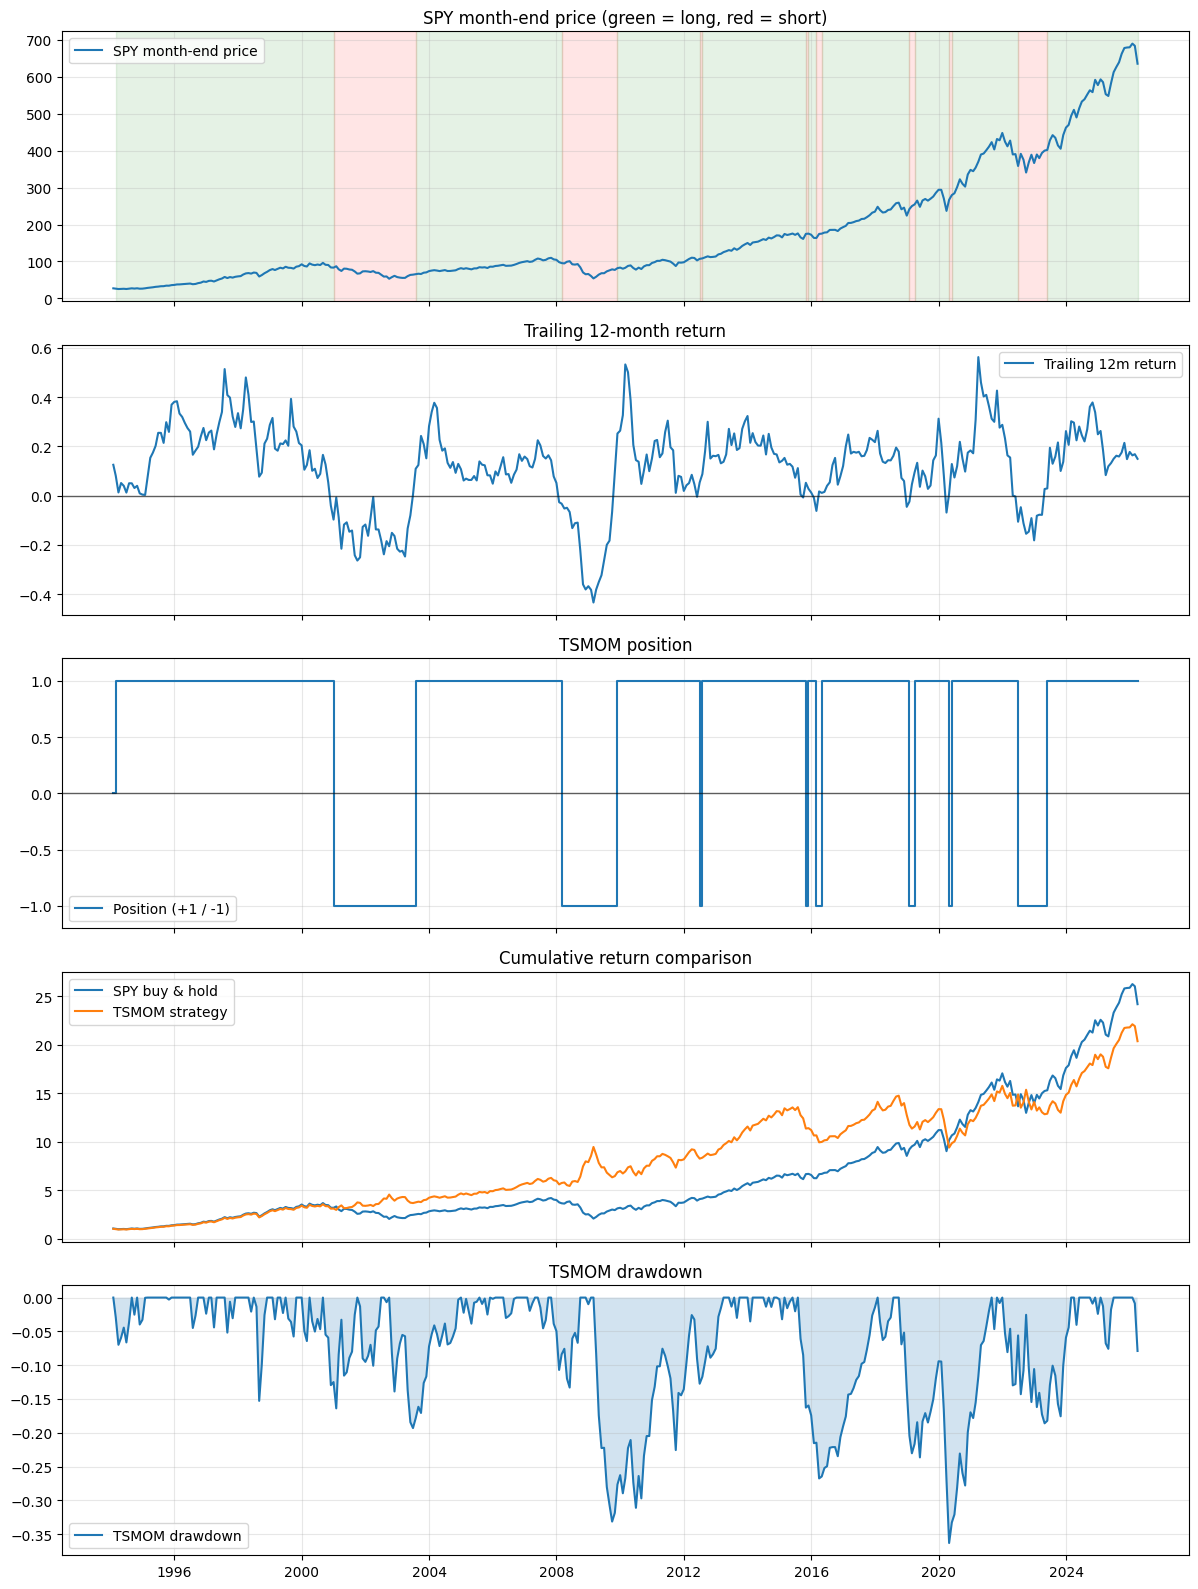

In [54]:
fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=True)

# 1. Month-end price with long/short regimes
axes[0].plot(out.index, out["month_end_price"], label=f"{ticker} month-end price")
shade_positions(axes[0], out["position"])
axes[0].set_title(f"{ticker} month-end price (green = long, red = short)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 2. Trailing 12m return
axes[1].plot(out.index, out["trailing_12m"].values, label="Trailing 12m return")
axes[1].axhline(0, color="black", linewidth=1, alpha=0.6)
axes[1].set_title("Trailing 12-month return")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# 3. Position
axes[2].step(out.index, out["position"].values, where="post", label="Position (+1 / -1)")
axes[2].axhline(0, color="black", linewidth=1, alpha=0.6)
axes[2].set_ylim(-1.2, 1.2)
axes[2].set_title("TSMOM position")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

# 4. Strategy vs asset cumulative return
axes[3].plot(asset_cum.index, asset_cum.values, label=f"{ticker} buy & hold")
axes[3].plot(strategy_cum.index, strategy_cum.values, label="TSMOM strategy")
axes[3].set_title("Cumulative return comparison")
axes[3].grid(True, alpha=0.3)
axes[3].legend()

# 5. Strategy drawdown
axes[4].plot(strategy_dd.index, strategy_dd.values, label="TSMOM drawdown")
axes[4].fill_between(strategy_dd.index, strategy_dd.values, 0, alpha=0.2)
axes[4].set_title("TSMOM drawdown")
axes[4].grid(True, alpha=0.3)
axes[4].legend()

plt.tight_layout()
plt.show()

This first illustration ignores transaction costs, slippage, financing details, and futures-specific roll mechanics. Its purpose is only to show the basic time-series momentum rule on a single asset.